In this notebook, different ways of combining kernels with Cellrank are tested. The notebook is also used to determine how many macrostates to use.

## Setup

In [1]:
import scanpy
import anndata
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import scvelo
import seaborn
import pandas
import sdevelo
import warnings
import cellrank
import moscot

(Working on SDEvelo 0.2.12)
2026-01-27 07:21:54


In [2]:
# Read input file
working_directory = "RNA Sequencing Data/"
adata = scanpy.read_h5ad(working_directory + "/velocity_sdevelo.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 12791 × 2000
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'latent_time', 'sde_velocity_self_transition', 'manual_root', 'manual_end', 'sde_velocity_pseudotime'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_sigma_1', 'fit_sigma_2'
    uns: 'log1p', 'neighbors', 'pca', 'sample_colors', 'sde_velocity_graph', 'sde_velocity_graph_neg', 'sde_velocity_params'
    obsm: 'X_fdl', 'X_pca', 'X_umap', 'sde_velocity_fdl'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'pred_s', 'pred_u', 'sde_velocity', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'


In [3]:
# Suppress warnings

warnings.simplefilter("ignore", category=UserWarning)

In [4]:
# Create velocity kernel

velocity_kernel = cellrank.kernels.VelocityKernel(adata, vkey="sde_velocity")
velocity_kernel.compute_transition_matrix()

  0%|          | 0/12791 [00:00<?, ?cell/s]

  0%|          | 0/12791 [00:00<?, ?cell/s]

VelocityKernel[n=12791, model='deterministic', similarity='correlation', softmax_scale=6.344]

In [5]:
# Create kernel based on latent time

latent_time_kernel = cellrank.kernels.PseudotimeKernel(adata, time_key = "latent_time")
latent_time_kernel.compute_transition_matrix()

  0%|          | 0/12791 [00:00<?, ?cell/s]

PseudotimeKernel[n=12791, dnorm=False, scheme='hard', frac_to_keep=0.3]

In [6]:
# Kernel based on gene expression similarity

connectivity_kernel = cellrank.kernels.ConnectivityKernel(adata)
connectivity_kernel.compute_transition_matrix()

ConnectivityKernel[n=12791, dnorm=True, key='connectivities']

## 0.8 velocity, 0.2 connectivity

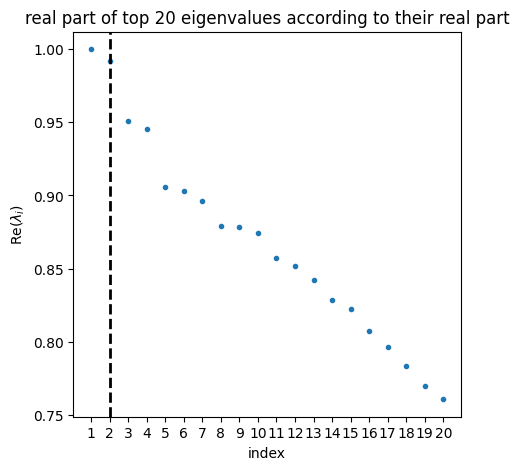

In [34]:
estimator = cellrank.estimators.GPCCA(0.8*velocity_kernel + 0.2*connectivity_kernel)

estimator.compute_schur()
estimator.plot_spectrum(real_only=True)

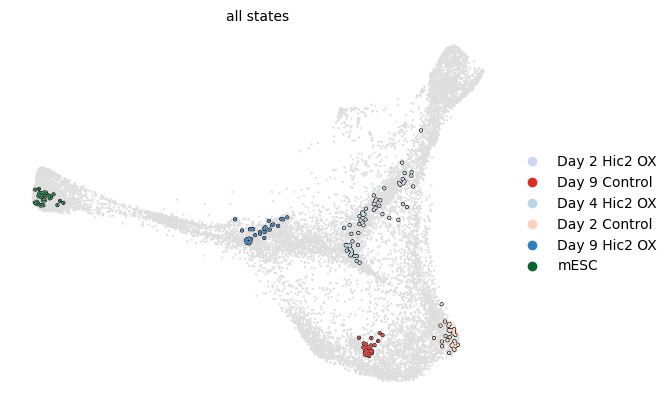

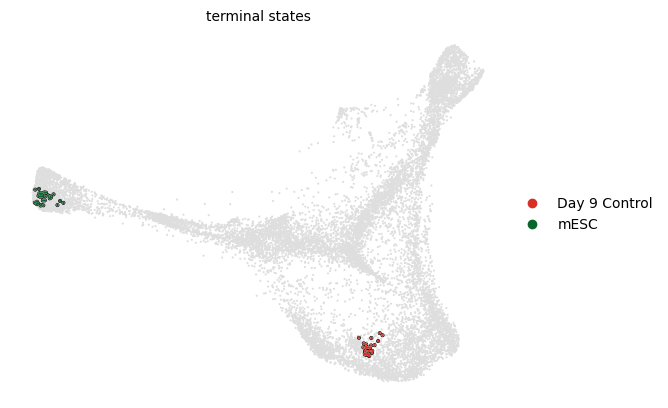

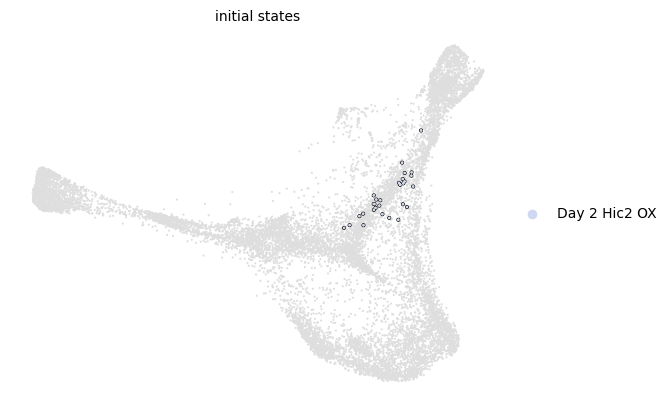

      Macrostate  Stability
5           mESC   0.989943
1  Day 9 Control   0.969092
3  Day 2 Control   0.965733
4  Day 9 Hic2 OX   0.953397
2  Day 4 Hic2 OX   0.916093
0  Day 2 Hic2 OX   0.902728


In [38]:
# Automatically determine number of macrostates
estimator.fit(n_states=[4, 10], cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
macrostate_names = estimator.coarse_T.index
stability_df = pandas.DataFrame({
    "Macrostate": macrostate_names,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

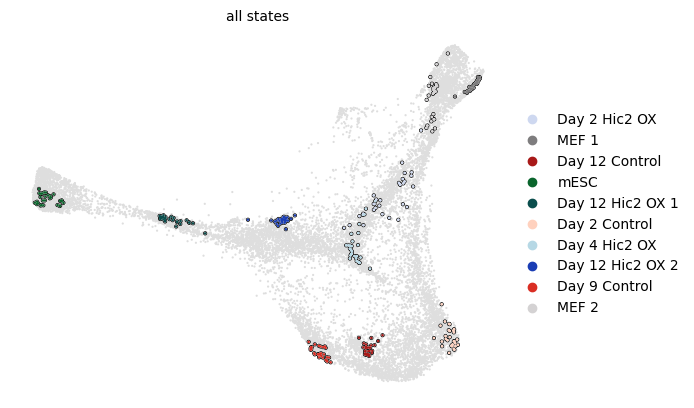

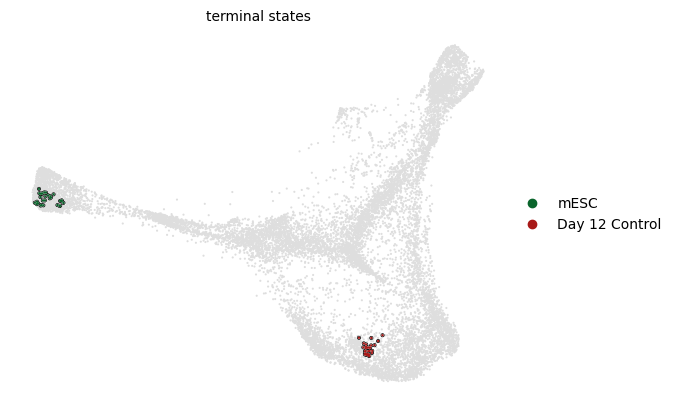

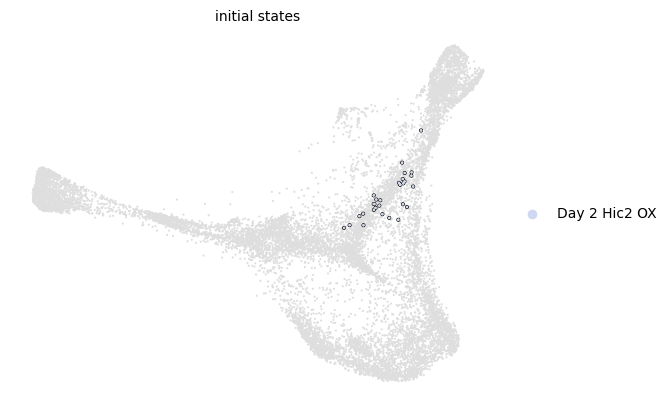

         Macrostate  Stability
2    Day 12 Control   0.964647
3              mESC   0.963009
4  Day 12 Hic2 OX_1   0.954413
8     Day 9 Control   0.943382
5     Day 2 Control   0.939598
7  Day 12 Hic2 OX_2   0.916947
9             MEF_2   0.905599
6     Day 4 Hic2 OX   0.898707
0     Day 2 Hic2 OX   0.876676
1             MEF_1   0.862208


In [39]:
# 10 macrostates

estimator.compute_macrostates(n_states=10, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
macrostate_names = estimator.coarse_T.index
stability_df = pandas.DataFrame({
    "Macrostate": macrostate_names,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

Using only velocity allows the model to identify terminal states, but the initial state is wrong even when MEFs are a macrostate.

## 0.6 velocity, 0.4 latent time

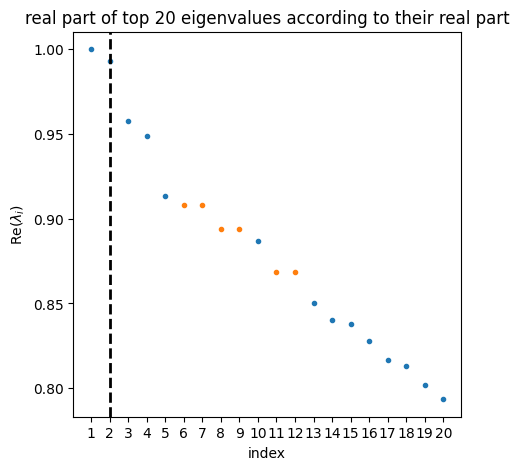

In [40]:
estimator = cellrank.estimators.GPCCA(0.6*velocity_kernel + 0.4*latent_time_kernel)

estimator.compute_schur()
estimator.plot_spectrum(real_only=True)

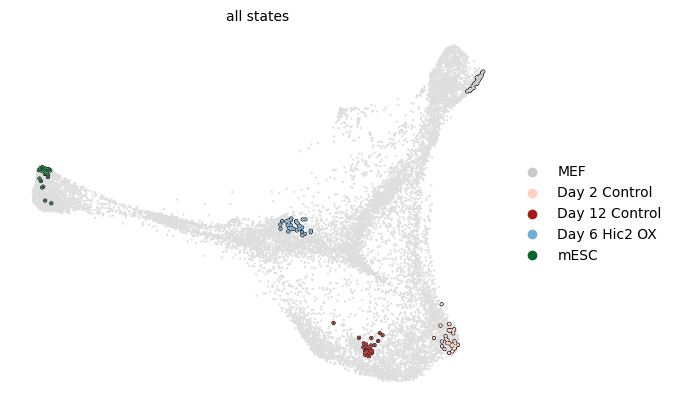

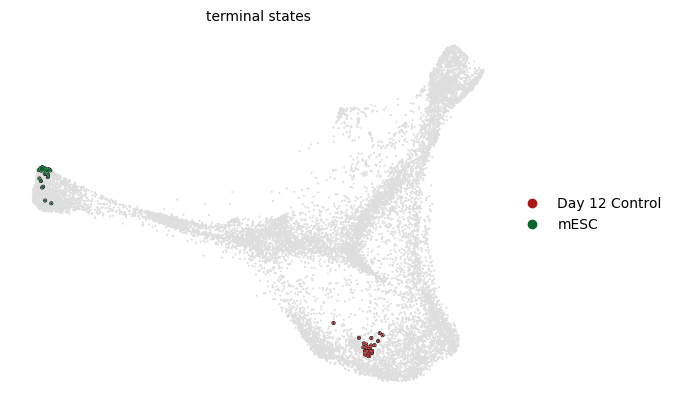

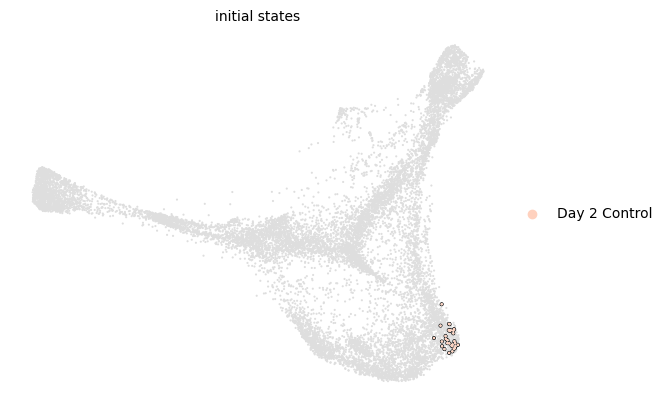

       Macrostate  Stability
4            mESC   0.999398
2  Day 12 Control   0.984170
1   Day 2 Control   0.963745
3   Day 6 Hic2 OX   0.953398
0             MEF   0.912482


In [41]:
# Automatically determine number of macrostates
estimator.fit(n_states=[4, 10], cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states(allow_overlap=True)
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

With only velocity and latent time, the initial state is not determined correctly. Terminal states are reasonable.

## 0.7 velocity, 0.1 latent time, 0.2 connectivity

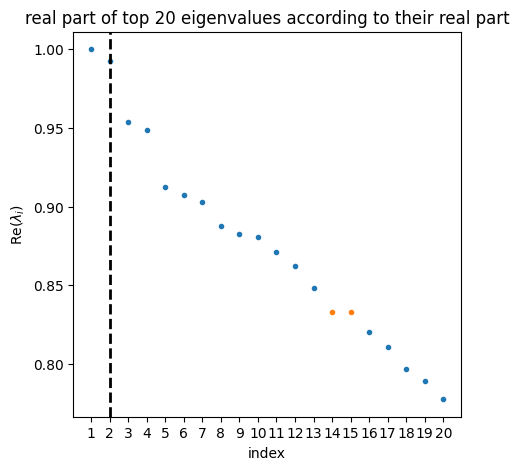

In [ ]:
estimator = cellrank.estimators.GPCCA(0.7*velocity_kernel + 0.1*latent_time_kernel + 0.2*connectivity_kernel)

estimator.compute_schur()
estimator.plot_spectrum(real_only=True)

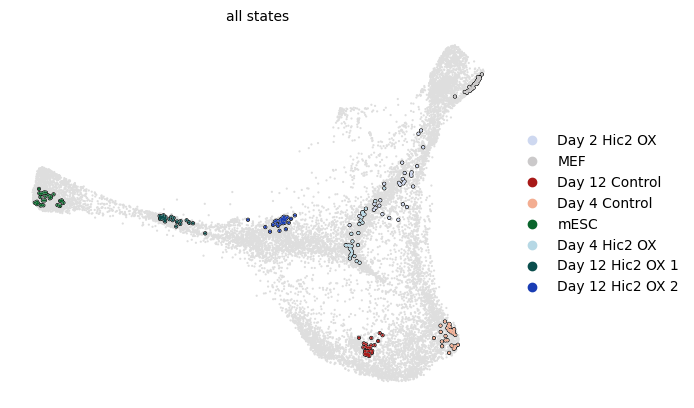

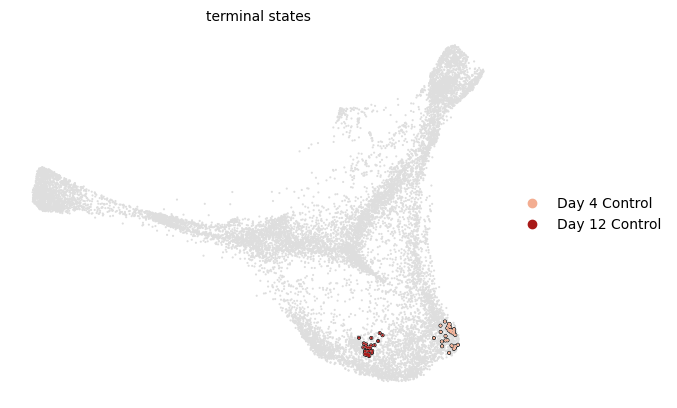

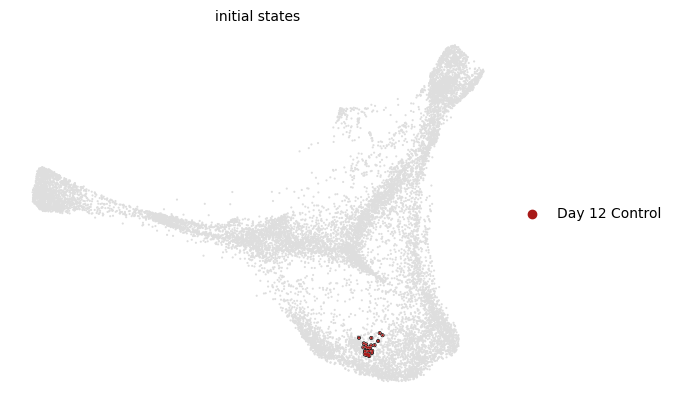

         Macrostate  Stability
2    Day 12 Control   0.970787
3     Day 4 Control   0.968995
4              mESC   0.963404
6  Day 12 Hic2 OX_1   0.951947
7  Day 12 Hic2 OX_2   0.950461
5     Day 4 Hic2 OX   0.913809
0     Day 2 Hic2 OX   0.903879
1               MEF   0.881733


In [ ]:
# Automatically determine number of macrostates
estimator.fit(n_states=[4, 10], cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states(allow_overlap=True)
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

0.1 latent time is not enough to correctly identify the initial state.

## 0.6 velocity, 0.2 latent time, 0.2 connectivity

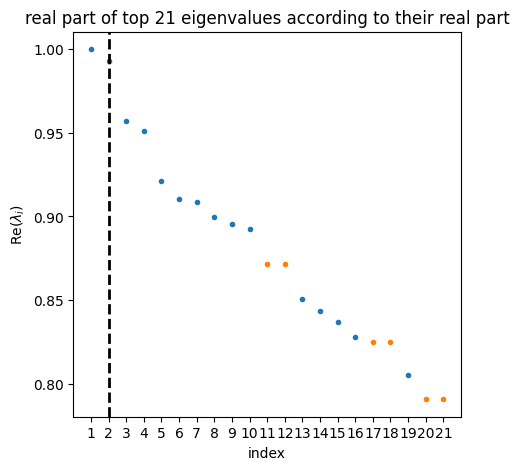

In [ ]:
estimator = cellrank.estimators.GPCCA(0.6*velocity_kernel + 0.2*latent_time_kernel + 0.2*connectivity_kernel)

estimator.compute_schur()
estimator.plot_spectrum(real_only=True)

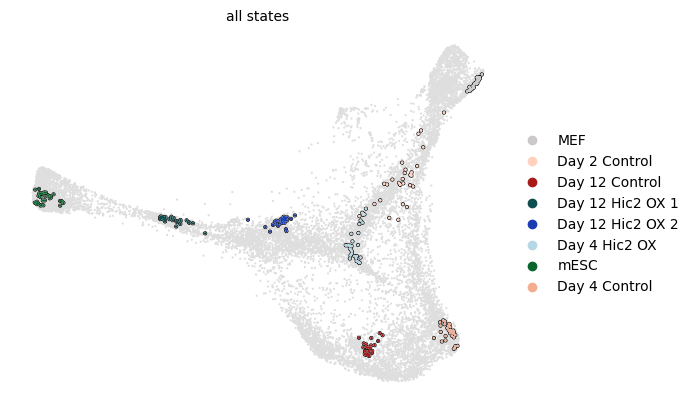

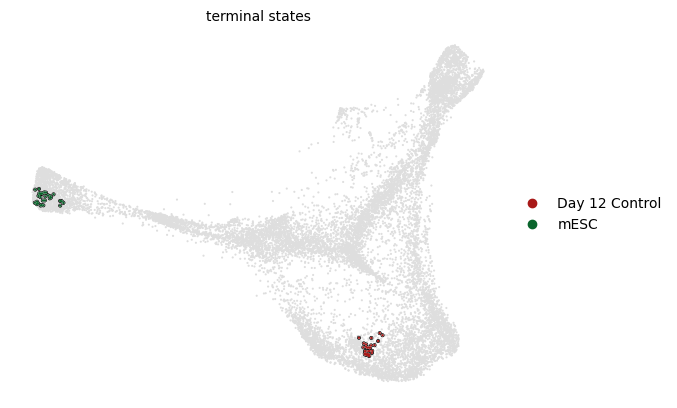

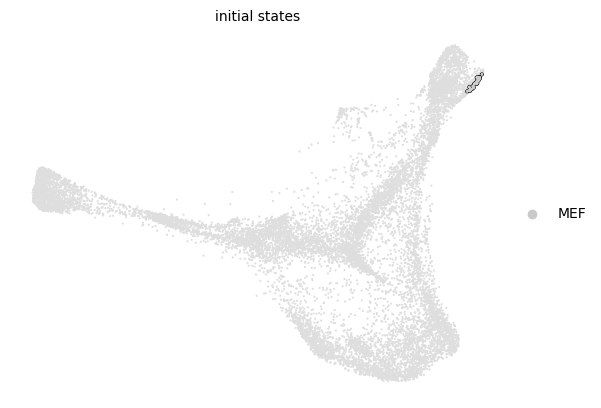

         Macrostate  Stability
6              mESC   0.975063
2    Day 12 Control   0.972570
7     Day 4 Control   0.970599
4  Day 12 Hic2 OX_2   0.951260
3  Day 12 Hic2 OX_1   0.943024
5     Day 4 Hic2 OX   0.918746
1     Day 2 Control   0.911604
0               MEF   0.899457


In [ ]:
# Automatically determine number of macrostates
estimator.fit(n_states=[4, 10], cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

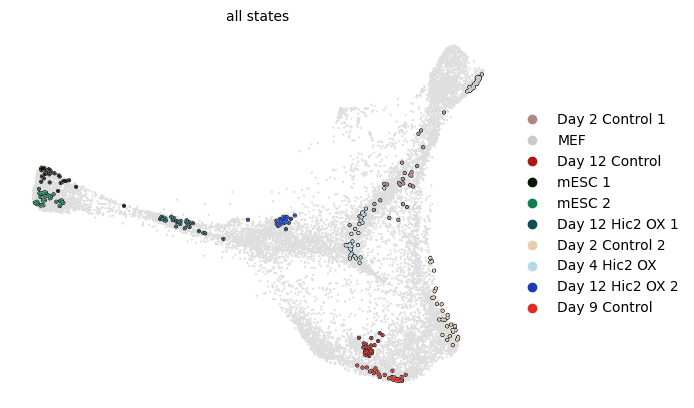

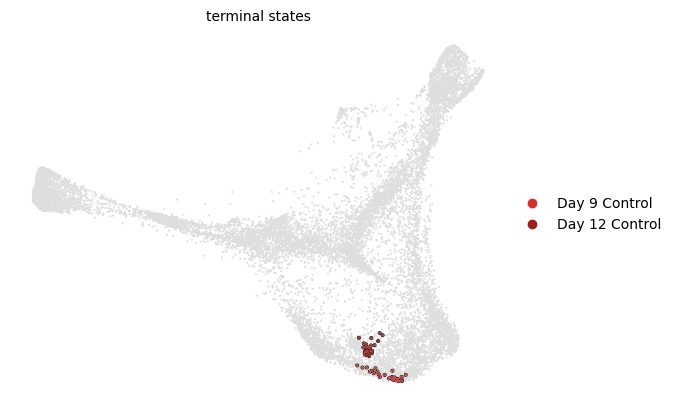

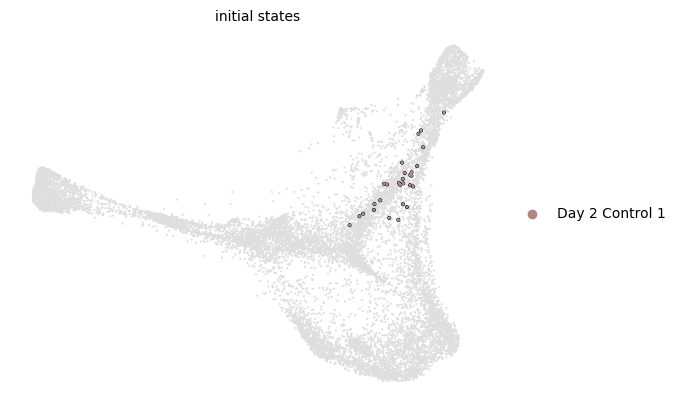

         Macrostate  Stability
2    Day 12 Control   0.968610
9     Day 9 Control   0.963681
3            mESC_1   0.953938
4            mESC_2   0.946485
8  Day 12 Hic2 OX_2   0.935647
5  Day 12 Hic2 OX_1   0.925785
6   Day 2 Control_2   0.922960
7     Day 4 Hic2 OX   0.920103
1               MEF   0.898204
0   Day 2 Control_1   0.895086


In [ ]:
# 10 macrostates

estimator.compute_macrostates(n_states=10, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
macrostate_names = estimator.coarse_T.index
stability_df = pandas.DataFrame({
    "Macrostate": macrostate_names,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

With 0.2 latent time, the initial state is correctly identified with 8 but not 10 macrostates. More time information is needed

## 0.5 velocity, 0.3 latent time, 0.2 connectivity

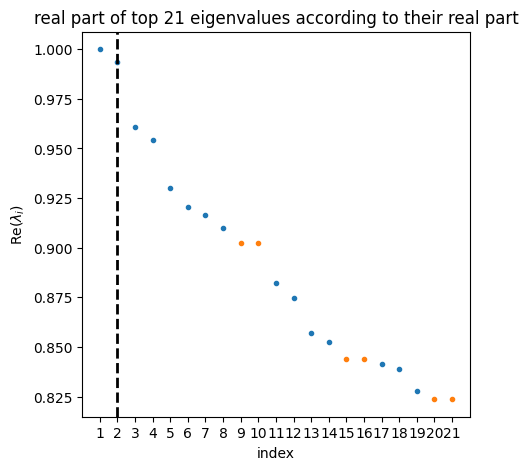

In [95]:
estimator = cellrank.estimators.GPCCA(0.5*velocity_kernel + 0.3*latent_time_kernel + 0.2*connectivity_kernel)

estimator.compute_schur()
estimator.plot_spectrum(real_only=True)

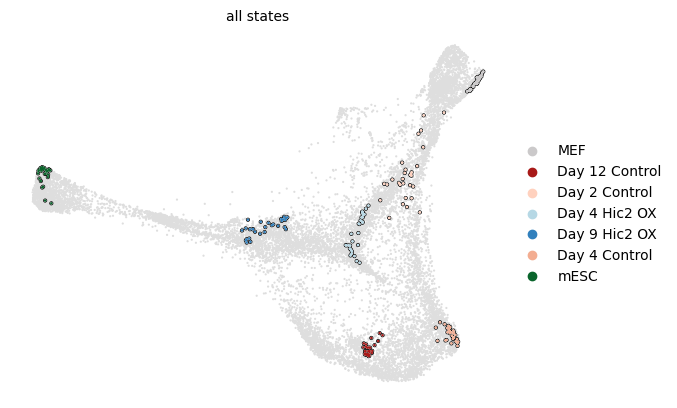

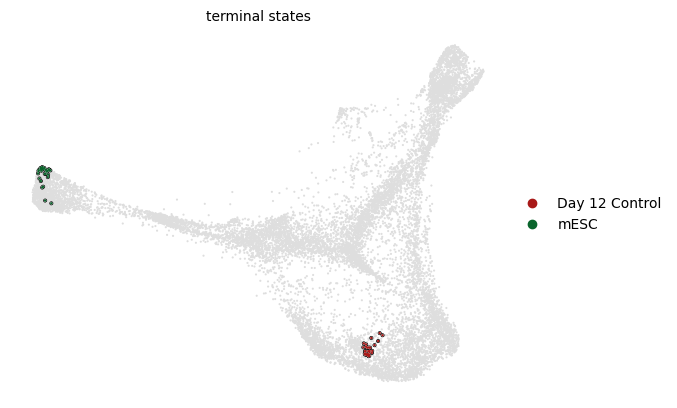

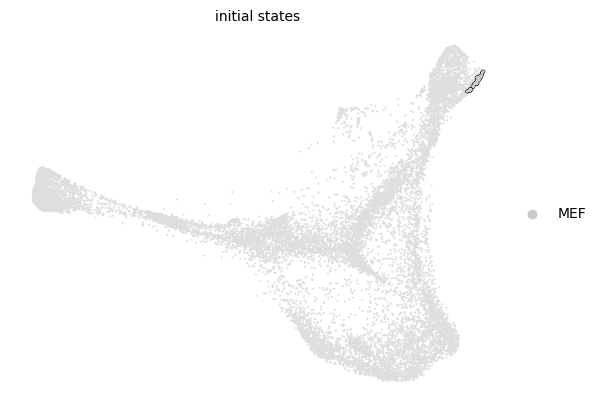

       Macrostate  Stability
6            mESC   0.995905
1  Day 12 Control   0.973201
5   Day 4 Control   0.968989
4   Day 9 Hic2 OX   0.960285
3   Day 4 Hic2 OX   0.937135
2   Day 2 Control   0.922084
0             MEF   0.918123


In [ ]:
# Automatically determine number of macrostates, 7 is optimal
estimator.fit(n_states=[4, 10], cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

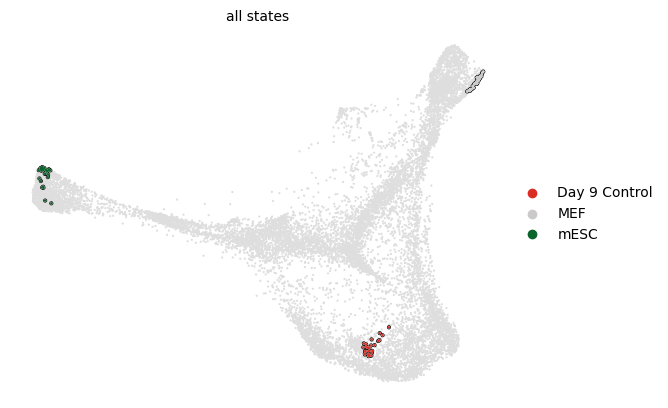

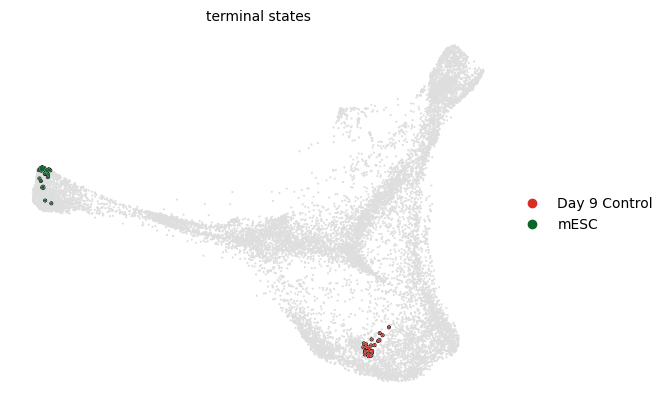

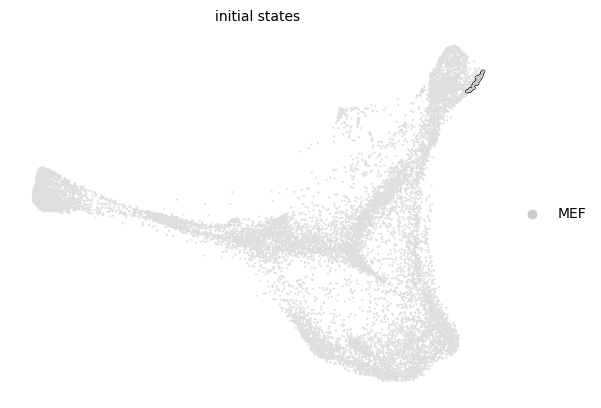

      Macrostate  Stability
2           mESC   0.999436
0  Day 9 Control   0.990279
1            MEF   0.964759


In [96]:
states=3

estimator.compute_macrostates(n_states=states, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

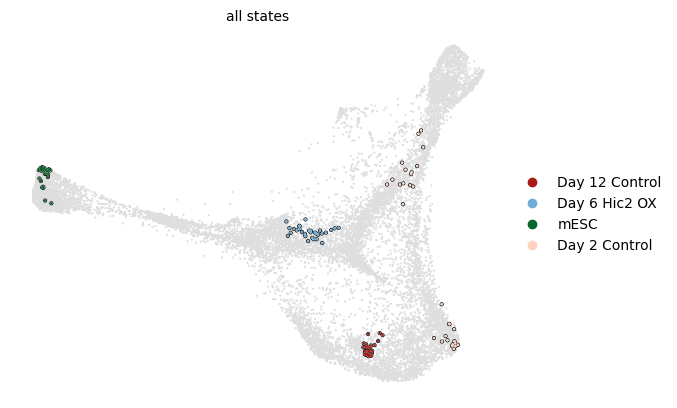

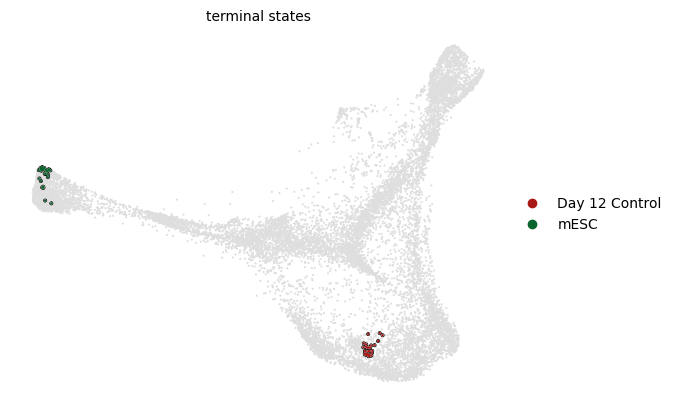

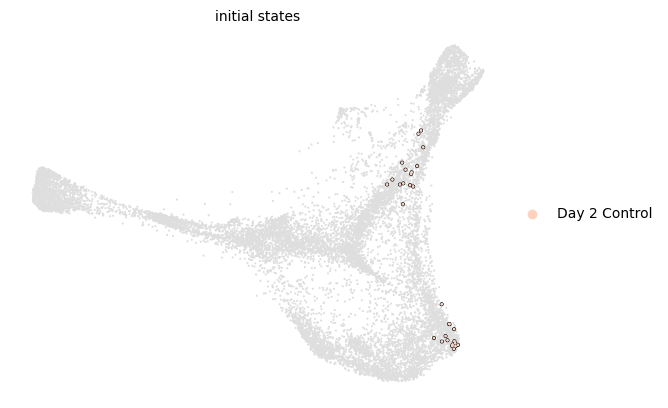

       Macrostate  Stability
2            mESC   0.999091
0  Day 12 Control   0.985347
1   Day 6 Hic2 OX   0.962849
3   Day 2 Control   0.961212


In [97]:
states=4

estimator.compute_macrostates(n_states=states, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

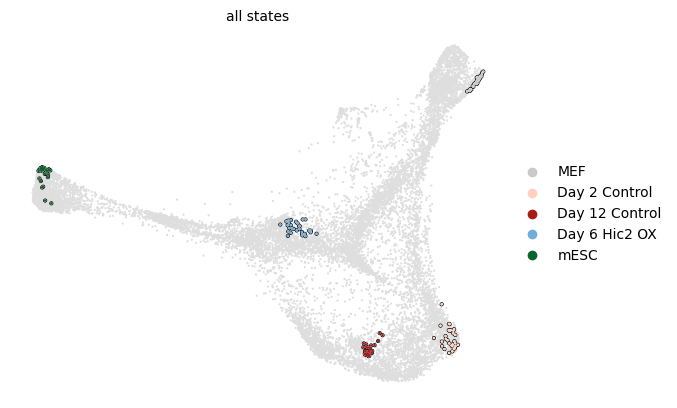

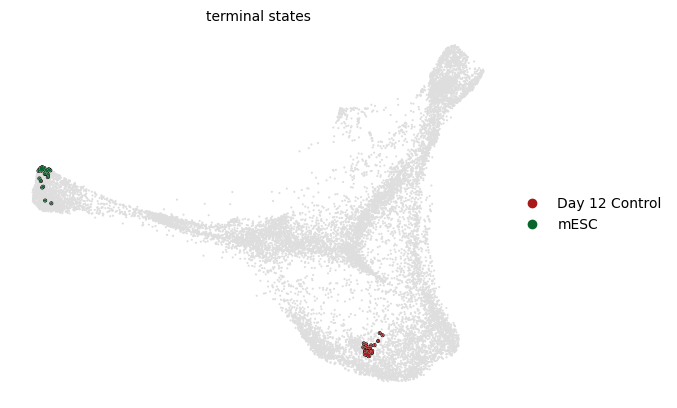

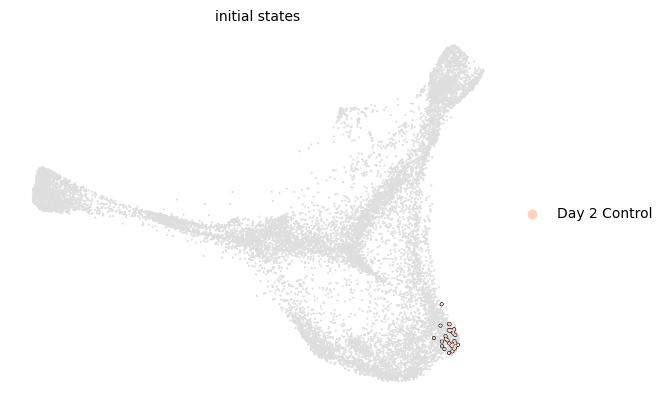

       Macrostate  Stability
4            mESC   0.999120
2  Day 12 Control   0.978257
1   Day 2 Control   0.971452
3   Day 6 Hic2 OX   0.963062
0             MEF   0.926909


In [98]:
states=5

estimator.compute_macrostates(n_states=states, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

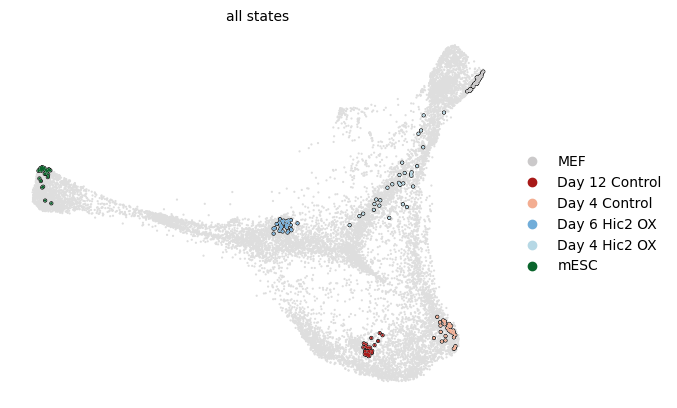

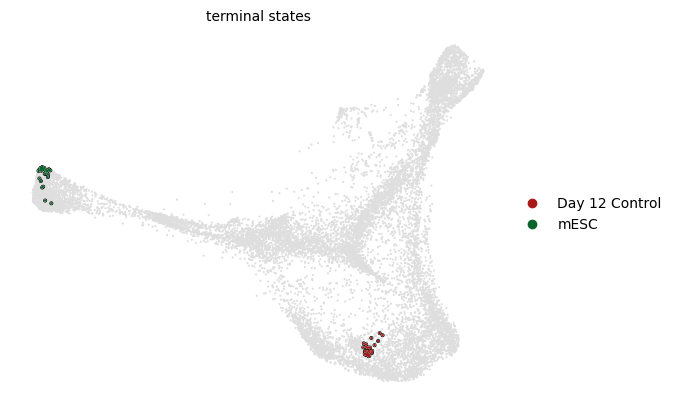

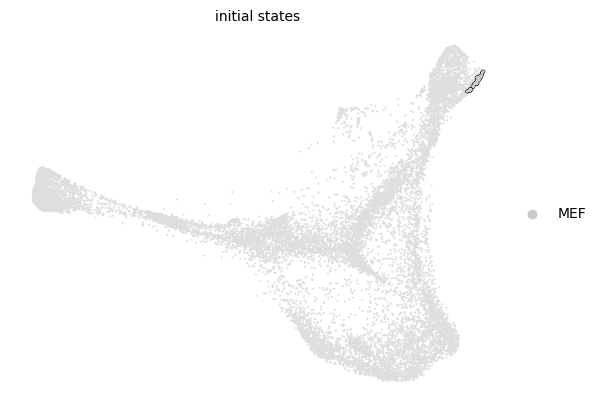

       Macrostate  Stability
5            mESC   0.998595
1  Day 12 Control   0.975068
2   Day 4 Control   0.974164
3   Day 6 Hic2 OX   0.962990
4   Day 4 Hic2 OX   0.928438
0             MEF   0.919821


In [99]:
states=6

estimator.compute_macrostates(n_states=states, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

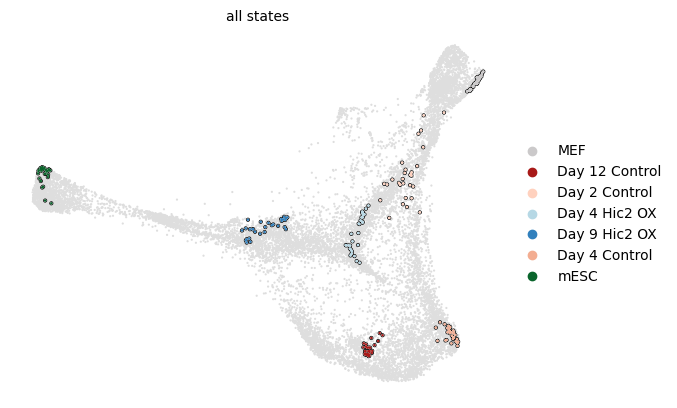

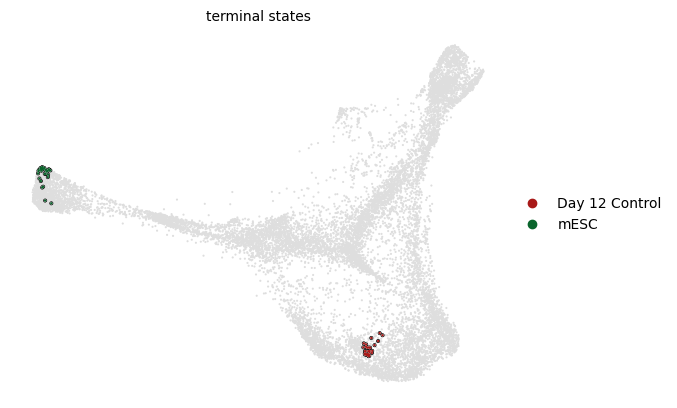

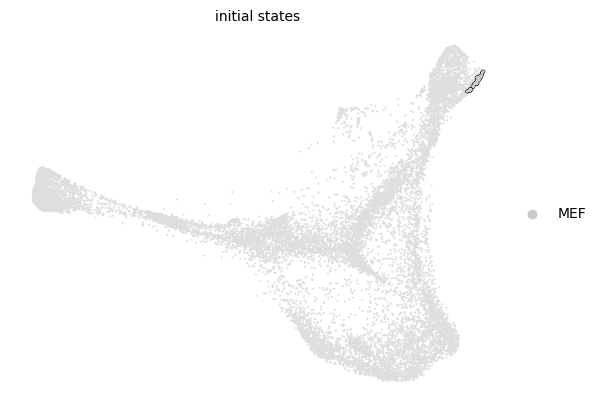

       Macrostate  Stability
6            mESC   0.995905
1  Day 12 Control   0.973201
5   Day 4 Control   0.968989
4   Day 9 Hic2 OX   0.960285
3   Day 4 Hic2 OX   0.937135
2   Day 2 Control   0.922084
0             MEF   0.918123


In [100]:
states=7

estimator.compute_macrostates(n_states=states, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

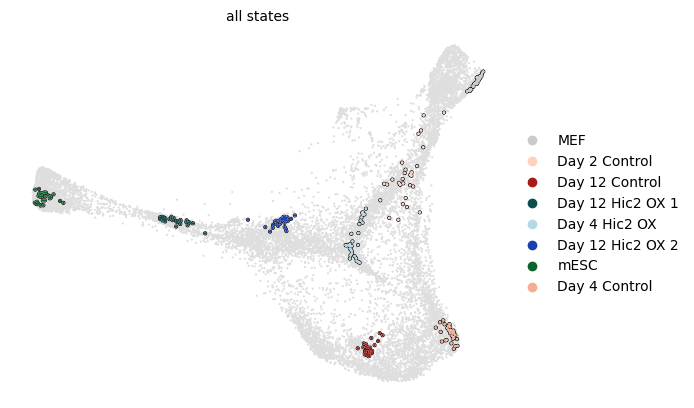

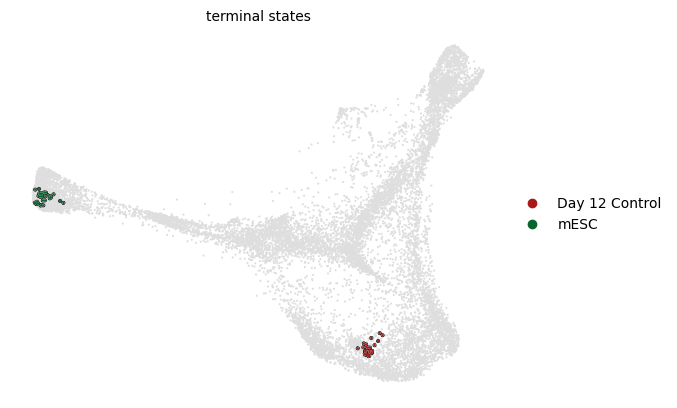

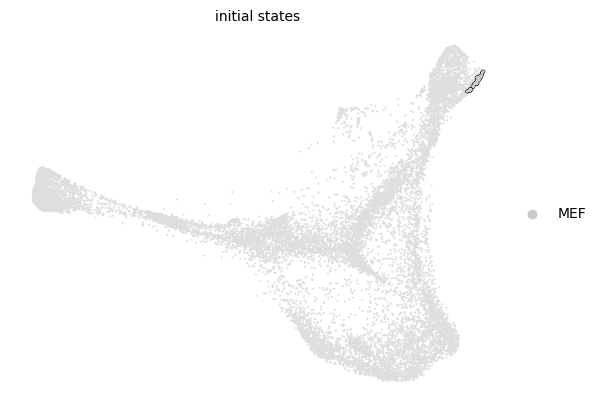

         Macrostate  Stability
6              mESC   0.979660
2    Day 12 Control   0.974475
7     Day 4 Control   0.971897
5  Day 12 Hic2 OX_2   0.950189
3  Day 12 Hic2 OX_1   0.944806
4     Day 4 Hic2 OX   0.927695
1     Day 2 Control   0.919461
0               MEF   0.917709


In [101]:
states=8

estimator.compute_macrostates(n_states=states, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

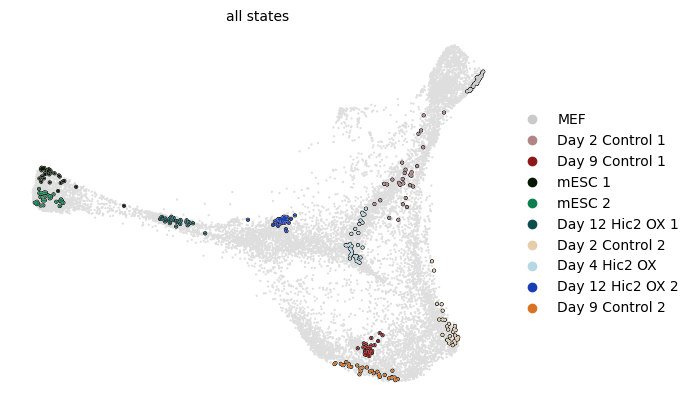

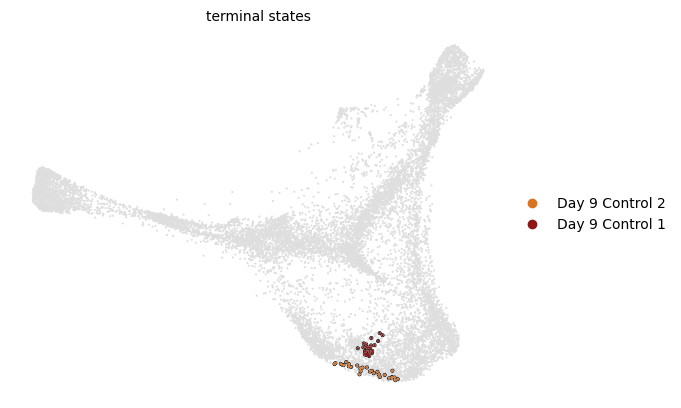

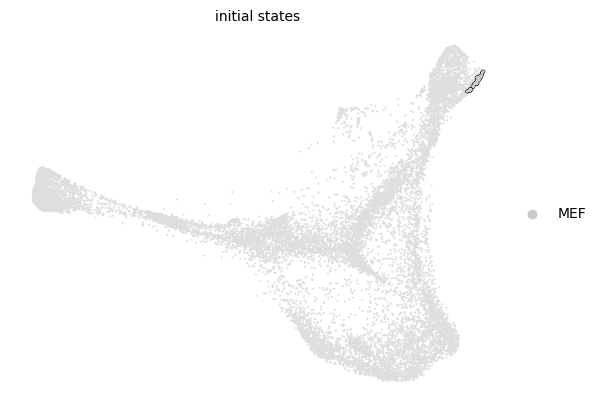

         Macrostate  Stability
2   Day 9 Control_1   0.969315
9   Day 9 Control_2   0.965940
3            mESC_1   0.955459
4            mESC_2   0.946779
8  Day 12 Hic2 OX_2   0.943151
6   Day 2 Control_2   0.937870
7     Day 4 Hic2 OX   0.931338
5  Day 12 Hic2 OX_1   0.930833
0               MEF   0.915985
1   Day 2 Control_1   0.893758


In [102]:
states=9

estimator.compute_macrostates(n_states=states, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

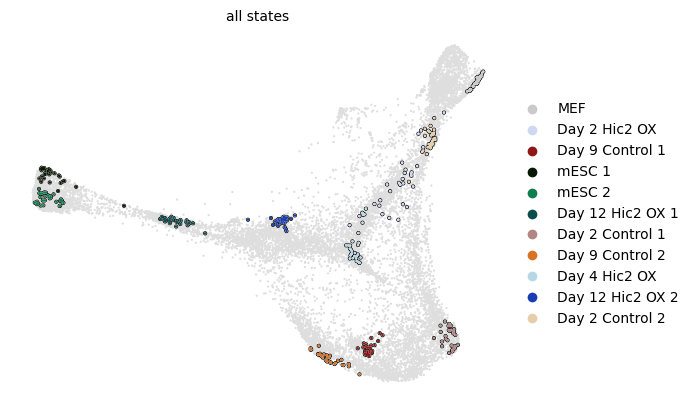

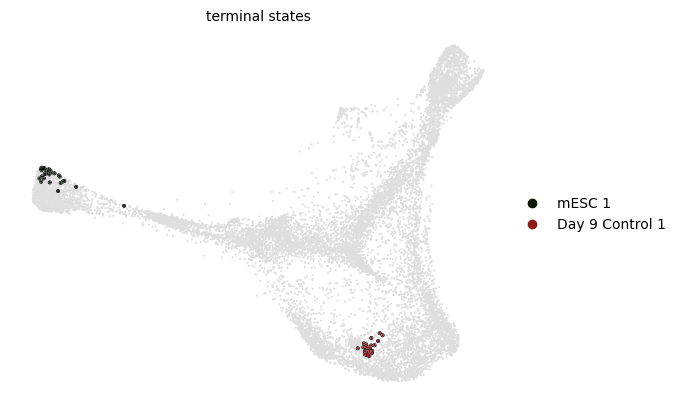

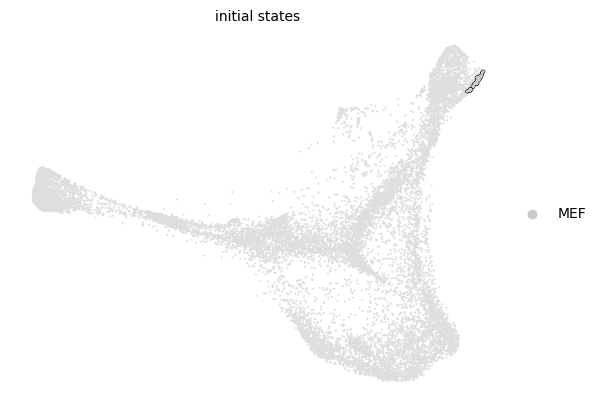

          Macrostate  Stability
2    Day 9 Control_1   0.971153
3             mESC_1   0.952984
6    Day 2 Control_1   0.952650
7    Day 9 Control_2   0.948684
4             mESC_2   0.948087
9   Day 12 Hic2 OX_2   0.939377
10   Day 2 Control_2   0.932307
5   Day 12 Hic2 OX_1   0.928856
8      Day 4 Hic2 OX   0.925691
0                MEF   0.916063
1      Day 2 Hic2 OX   0.856999


In [103]:
states=11

estimator.compute_macrostates(n_states=states, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

This combination of kernels consistently identifies the correct initial and terminal states with between 6 and 8 macrostates. 3 and 11 macrostates also work fine.

## 0.4 velocity, 0.4 latent time, 0.2 connectivity

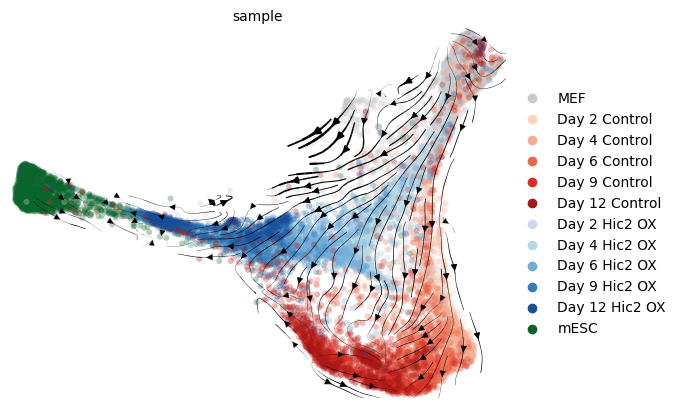

In [108]:
(0.4*velocity_kernel + 0.4*latent_time_kernel + 0.2*connectivity_kernel).plot_projection(basis="fdl", color="sample", legend_loc="right margin")

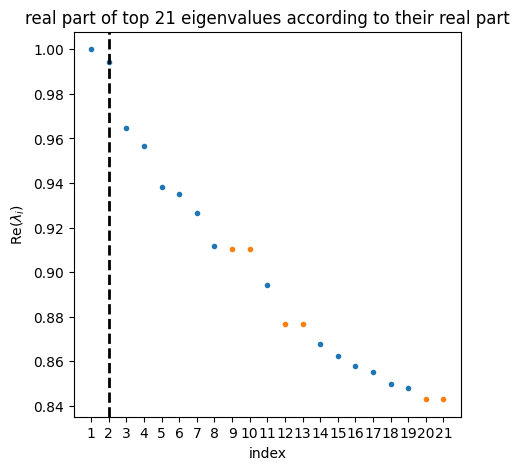

In [104]:
estimator = cellrank.estimators.GPCCA(0.4*velocity_kernel + 0.4*latent_time_kernel + 0.2*connectivity_kernel)

estimator.compute_schur()
estimator.plot_spectrum(real_only=True)

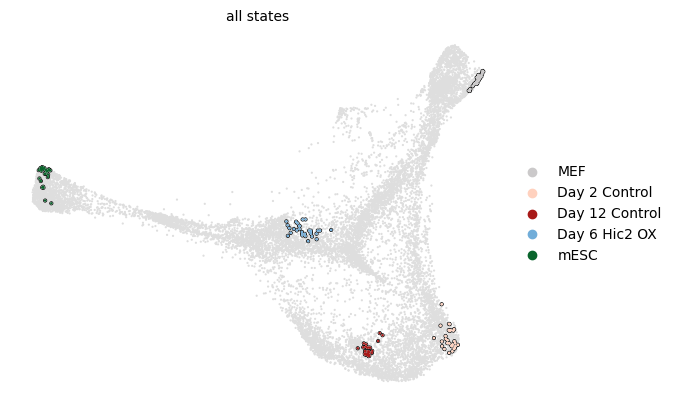

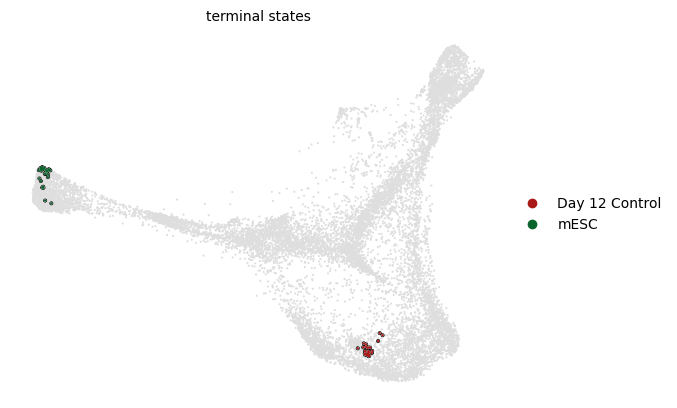

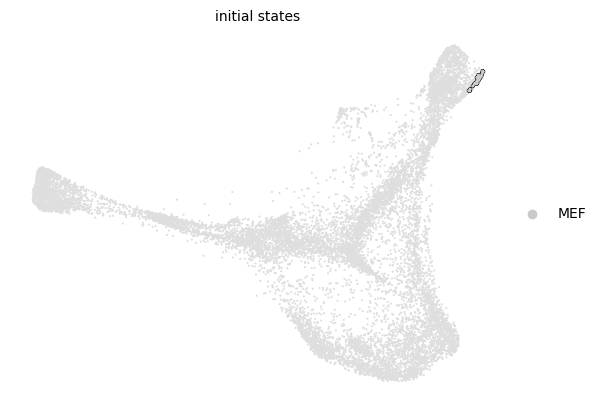

       Macrostate  Stability
4            mESC   0.998798
2  Day 12 Control   0.981956
1   Day 2 Control   0.969982
3   Day 6 Hic2 OX   0.966000
0             MEF   0.937341


In [ ]:
# Automatically determine number of macrostates, 5 is optimal
estimator.fit(n_states=[4, 10], cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

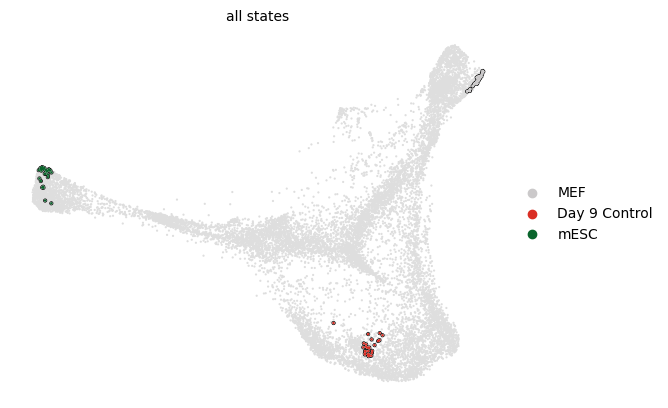

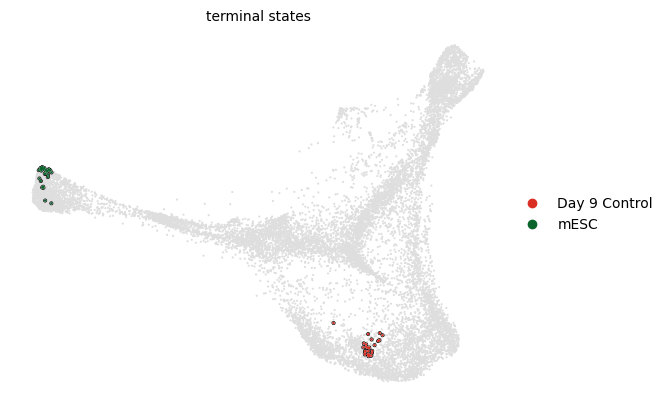

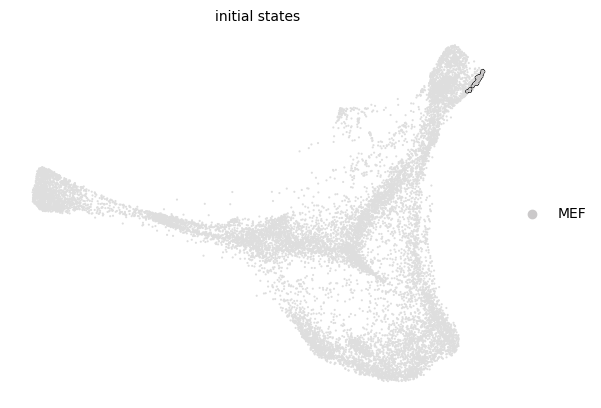

      Macrostate  Stability
2           mESC   0.999311
1  Day 9 Control   0.991359
0            MEF   0.968205


In [91]:
# 3 macrostates

estimator.compute_macrostates(n_states=3, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

In [ ]:
# 4 macrostates

estimator.compute_macrostates(n_states=4, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

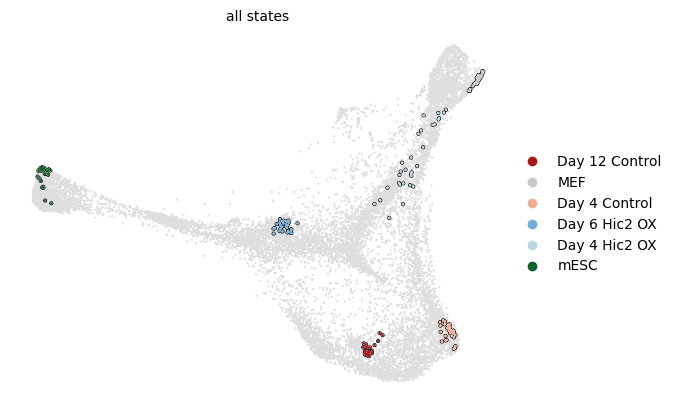

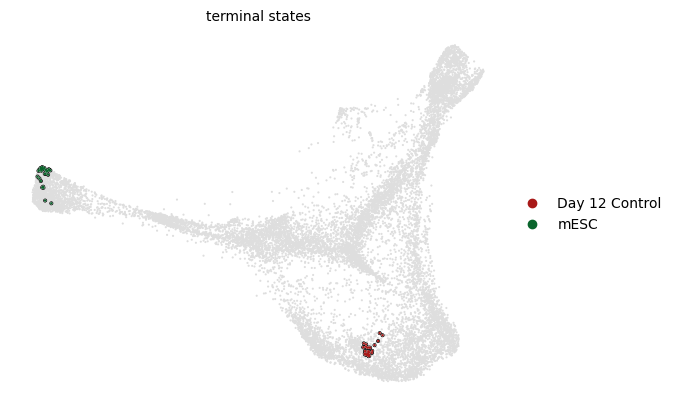

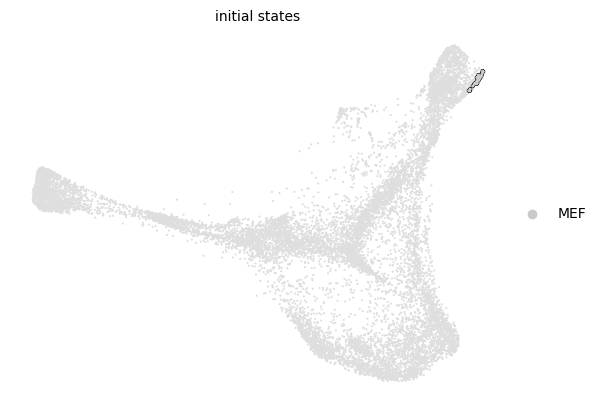

       Macrostate  Stability
5            mESC   0.998445
0  Day 12 Control   0.978060
2   Day 4 Control   0.974706
3   Day 6 Hic2 OX   0.965133
4   Day 4 Hic2 OX   0.938662
1             MEF   0.934330


In [92]:
# 6 macrostates

estimator.compute_macrostates(n_states=6, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

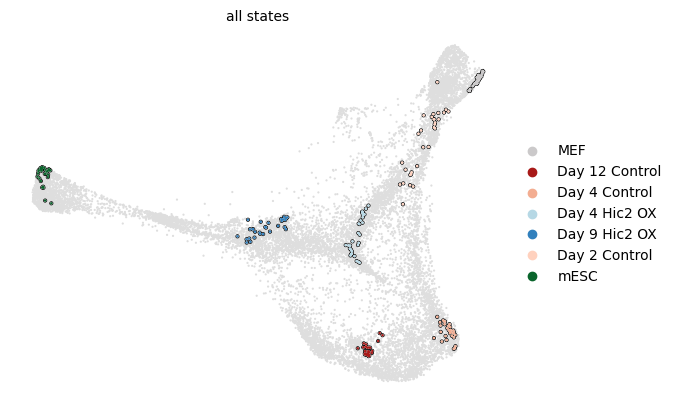

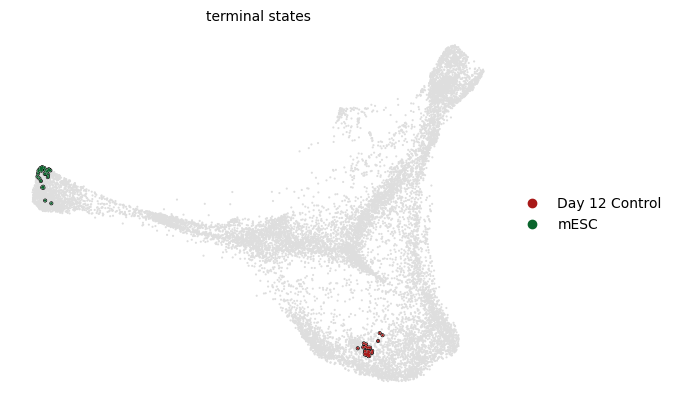

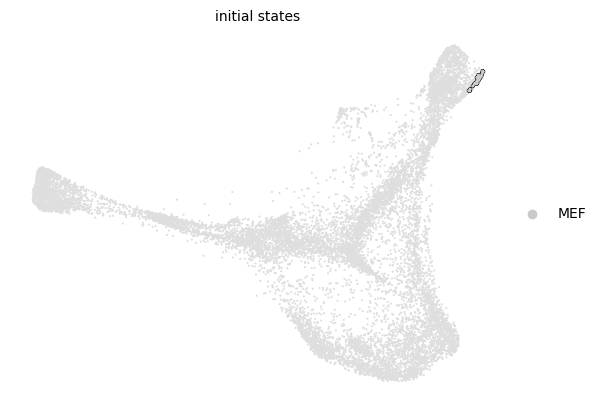

       Macrostate  Stability
6            mESC   0.996307
1  Day 12 Control   0.976904
2   Day 4 Control   0.972855
4   Day 9 Hic2 OX   0.964469
3   Day 4 Hic2 OX   0.940375
0             MEF   0.936240
5   Day 2 Control   0.928947


In [76]:
# 7 macrostates

estimator.compute_macrostates(n_states=7, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

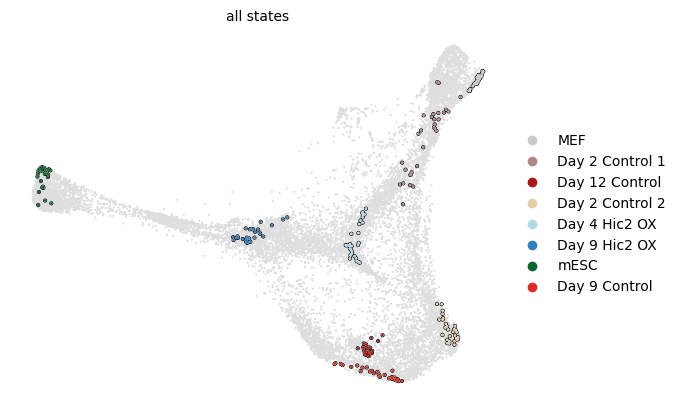

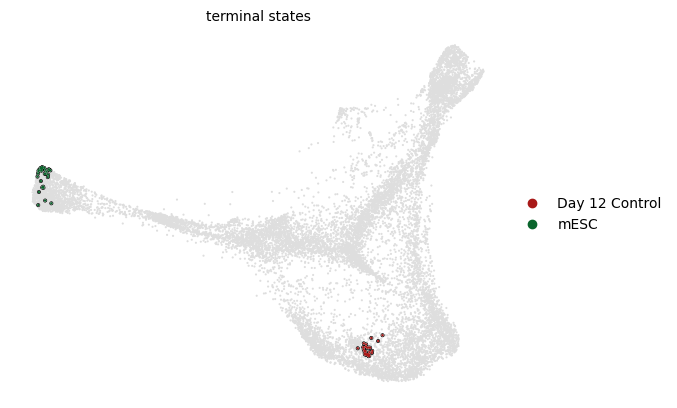

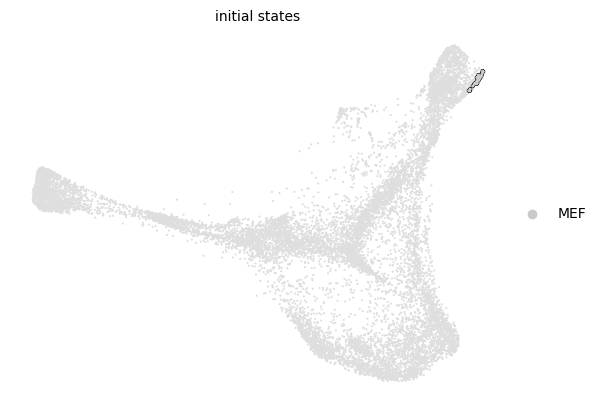

        Macrostate  Stability
6             mESC   0.995400
2   Day 12 Control   0.971293
5    Day 9 Hic2 OX   0.968644
7    Day 9 Control   0.959729
3  Day 2 Control_2   0.943888
4    Day 4 Hic2 OX   0.943720
0              MEF   0.931374
1  Day 2 Control_1   0.913847


In [93]:
# 8 macrostates

estimator.compute_macrostates(n_states=8, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

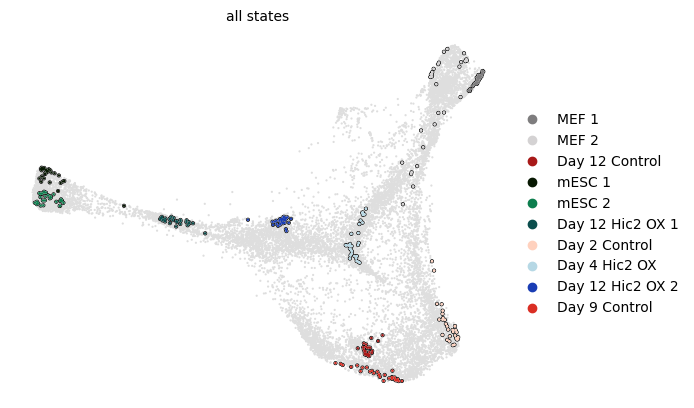

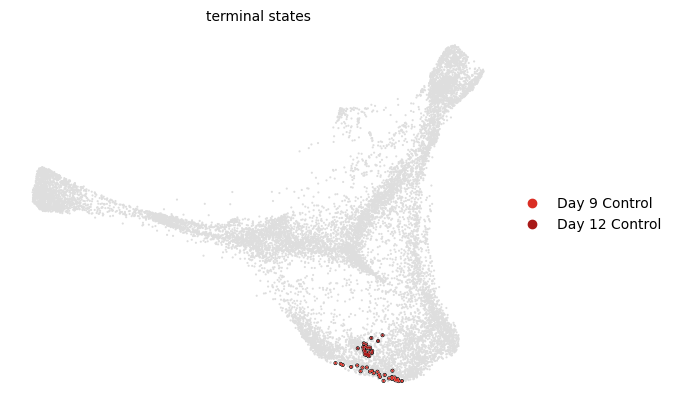

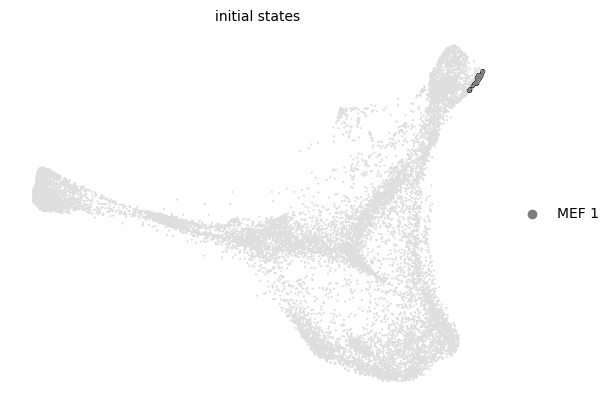

         Macrostate  Stability
2    Day 12 Control   0.970839
9     Day 9 Control   0.966999
3            mESC_1   0.956207
4            mESC_2   0.948236
8  Day 12 Hic2 OX_2   0.946666
6     Day 2 Control   0.946420
7     Day 4 Hic2 OX   0.938296
5  Day 12 Hic2 OX_1   0.937021
0             MEF_1   0.930671
1             MEF_2   0.907312


In [94]:
# 9 macrostates (10 due to complex conjugate)

estimator.compute_macrostates(n_states=9, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

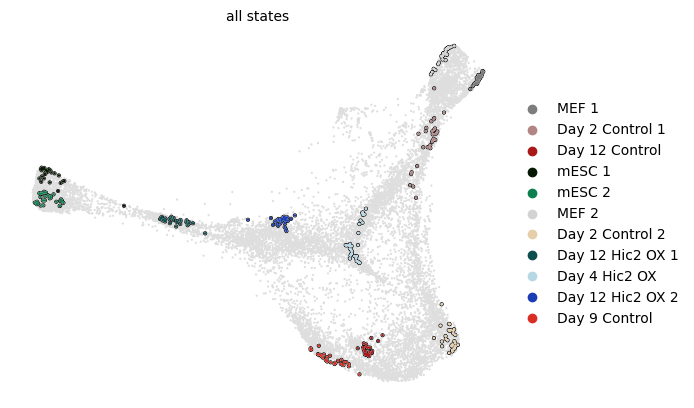

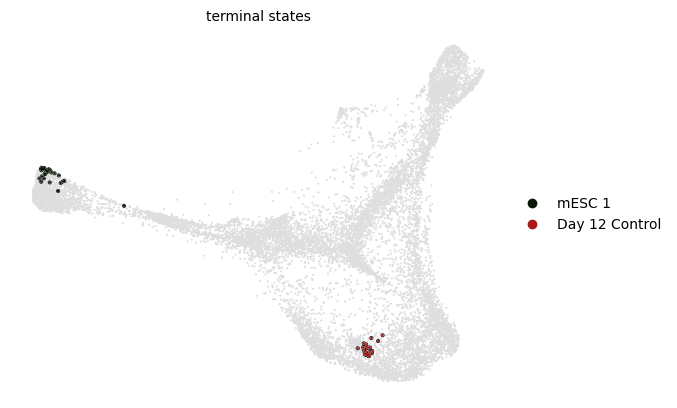

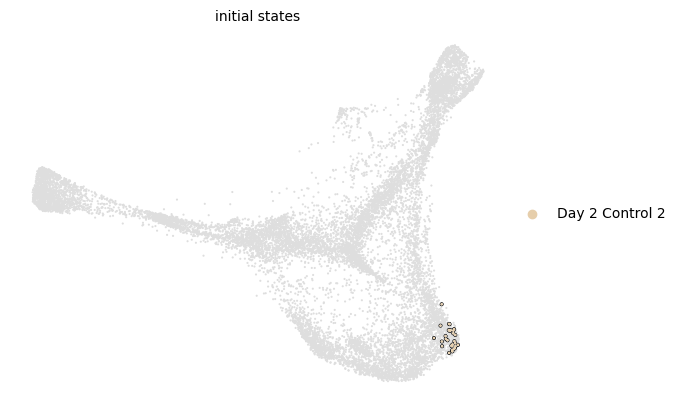

          Macrostate  Stability
2     Day 12 Control   0.971973
3             mESC_1   0.960901
10     Day 9 Control   0.952096
6    Day 2 Control_2   0.950775
9   Day 12 Hic2 OX_2   0.944065
1    Day 2 Control_1   0.942514
4             mESC_2   0.941424
7   Day 12 Hic2 OX_1   0.940915
8      Day 4 Hic2 OX   0.935162
0              MEF_1   0.934620
5              MEF_2   0.868684


In [106]:
# 11 macrostates

estimator.compute_macrostates(n_states=11, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="eigengap")
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)

# Plot stability of macrostates
stability_values = estimator.coarse_T.values.diagonal()
stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)
print(stability_df)

Reducing the amount of velocity from 0.5 to 0.4 makes the model find the initial state more robustly when the number of states is lower. 3, 4 or 5 states give the same initial and terminal states as when using 6, 7 or 8. 10 states is still too much, since the mESC state is split in two. 0.4 velocity, 0.4 latent time and 0.2 connectivity appears to be optimal. It works as well as 0.5 velocity with 6 or more states, and better with fewer than 6 states.